In [1]:
import numpy as np
import pandas as pd
import pickle, matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

OUT_DIR = Path('../data/processed')
train_df  = pd.read_parquet(OUT_DIR / 'train.parquet')
val_df    = pd.read_parquet(OUT_DIR / 'val.parquet')
test_df   = pd.read_parquet(OUT_DIR / 'test.parquet')

with open(OUT_DIR / 'meta.pkl', 'rb') as f:
    meta = pickle.load(f)

N_USERS, N_MOVIES = meta['n_users'], meta['n_movies']
idx2movie = meta['idx2movie']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | Users: {N_USERS:,} | Films: {N_MOVIES:,}')

Device: cpu | Users: 610 | Films: 2,269


In [2]:
class MovieDataset(Dataset):
    def __init__(self, df, n_movies):
        self.users      = torch.LongTensor(df['user_idx'].values)
        self.items      = torch.LongTensor(df['movie_idx'].values)
        self.n_movies   = n_movies
        self.user_items = df.groupby('user_idx')['movie_idx'].apply(set).to_dict()

    def __len__(self): return len(self.users)

    def __getitem__(self, idx):
        user = self.users[idx].item()
        pos  = self.items[idx].item()
        neg  = np.random.randint(self.n_movies)
        while neg in self.user_items.get(user, set()):
            neg = np.random.randint(self.n_movies)
        return torch.tensor(user), torch.tensor(pos), torch.tensor(neg)

train_loader = DataLoader(MovieDataset(train_df, N_MOVIES), batch_size=512, shuffle=True)
val_loader   = DataLoader(MovieDataset(val_df,   N_MOVIES), batch_size=512, shuffle=False)
test_loader  = DataLoader(MovieDataset(test_df,  N_MOVIES), batch_size=512, shuffle=False)
print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 127 | Val: 1 | Test: 1


In [3]:
class NeuralCF(nn.Module):
    """Neural CF : MF + MLP sur embeddings (He et al. 2017)."""
    def __init__(self, n_users, n_movies, emb_dim=64, mlp_layers=[256,128,64], dropout=0.3):
        super().__init__()
        self.user_emb_mf   = nn.Embedding(n_users,  emb_dim)
        self.movie_emb_mf  = nn.Embedding(n_movies, emb_dim)
        self.user_emb_mlp  = nn.Embedding(n_users,  emb_dim)
        self.movie_emb_mlp = nn.Embedding(n_movies, emb_dim)

        mlp_input = emb_dim * 2
        layers = []
        for out_dim in mlp_layers:
            layers += [nn.Linear(mlp_input, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            mlp_input = out_dim
        self.mlp    = nn.Sequential(*layers)
        self.output = nn.Linear(emb_dim + mlp_layers[-1], 1)
        for emb in [self.user_emb_mf, self.movie_emb_mf, self.user_emb_mlp, self.movie_emb_mlp]:
            nn.init.normal_(emb.weight, std=0.01)

    def forward(self, user, item):
        mf_out  = self.user_emb_mf(user) * self.movie_emb_mf(item)
        mlp_out = self.mlp(torch.cat([self.user_emb_mlp(user), self.movie_emb_mlp(item)], dim=-1))
        return self.output(torch.cat([mf_out, mlp_out], dim=-1)).squeeze()

model = NeuralCF(N_USERS, N_MOVIES).to(DEVICE)
print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')

Paramètres : 442,817


In [6]:
def bpr_loss(pos_scores, neg_scores):
    """Bayesian Personalized Ranking loss."""
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

def hit_rate_at_k(model, df, n_movies, k=10, n_users_eval=200):
    model.eval()
    hits, all_items = 0, torch.arange(n_movies).to(DEVICE)
    users_eval = df['user_idx'].unique()[:n_users_eval]
    with torch.no_grad():
        for uid in users_eval:
            pos_items = set(df[df['user_idx'] == uid]['movie_idx'].values)
            if not pos_items: continue
            pos  = list(pos_items)[0]
            scores = model(torch.tensor([uid]*n_movies).to(DEVICE), all_items).cpu().numpy()
            hits += int(pos in set(np.argsort(scores)[::-1][:k]))
    return hits / len(users_eval)

def ndcg_at_k(model, df, n_movies, k=10, n_users_eval=200):
    model.eval()
    scores_list, all_items = [], torch.arange(n_movies).to(DEVICE)
    users_eval = df['user_idx'].unique()[:n_users_eval]
    with torch.no_grad():
        for uid in users_eval:
            pos_items = set(df[df['user_idx'] == uid]['movie_idx'].values)
            if not pos_items: continue
            pos    = list(pos_items)[0]
            scores = model(torch.tensor([uid]*n_movies).to(DEVICE), all_items).cpu().numpy()
            top_k  = list(np.argsort(scores)[::-1][:k])
            scores_list.append(1/np.log2(top_k.index(pos)+2) if pos in top_k else 0.0)
    return np.mean(scores_list)

print('Métriques OK : bpr_loss · hit_rate_at_k · ndcg_at_k')

Métriques OK : bpr_loss · hit_rate_at_k · ndcg_at_k


In [7]:
EPOCHS, LR, PATIENCE = 15, 0.001, 3
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

history = {'train_loss': [], 'val_hr': [], 'val_ndcg': []}
best_ndcg, best_state, patience_ctr = 0, None, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for user, pos, neg in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        user, pos, neg = user.to(DEVICE), pos.to(DEVICE), neg.to(DEVICE)
        loss = bpr_loss(model(user, pos), model(user, neg))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()

    val_hr   = hit_rate_at_k(model, val_df, N_MOVIES)
    val_ndcg = ndcg_at_k(model, val_df, N_MOVIES)
    scheduler.step(1 - val_ndcg)
    history['train_loss'].append(total_loss / len(train_loader))
    history['val_hr'].append(val_hr)
    history['val_ndcg'].append(val_ndcg)
    print(f'Epoch {epoch:2d} | Loss: {total_loss/len(train_loader):.4f} | HR@10: {val_hr:.4f} | NDCG@10: {val_ndcg:.4f}')

    if val_ndcg > best_ndcg:
        best_ndcg, patience_ctr = val_ndcg, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE: print('Early stopping'); break

model.load_state_dict(best_state)
print(f'Meilleur NDCG@10 : {best_ndcg:.4f}')

Epoch  1 | Loss: 0.5664 | HR@10: 0.0000 | NDCG@10: 0.0000


Epoch  2 | Loss: 0.4733 | HR@10: 0.0526 | NDCG@10: 0.0332


Epoch  3 | Loss: 0.4250 | HR@10: 0.0526 | NDCG@10: 0.0166


Epoch  4 | Loss: 0.3799 | HR@10: 0.0000 | NDCG@10: 0.0000


Epoch  5 | Loss: 0.3536 | HR@10: 0.0000 | NDCG@10: 0.0000
Early stopping
Meilleur NDCG@10 : 0.0332


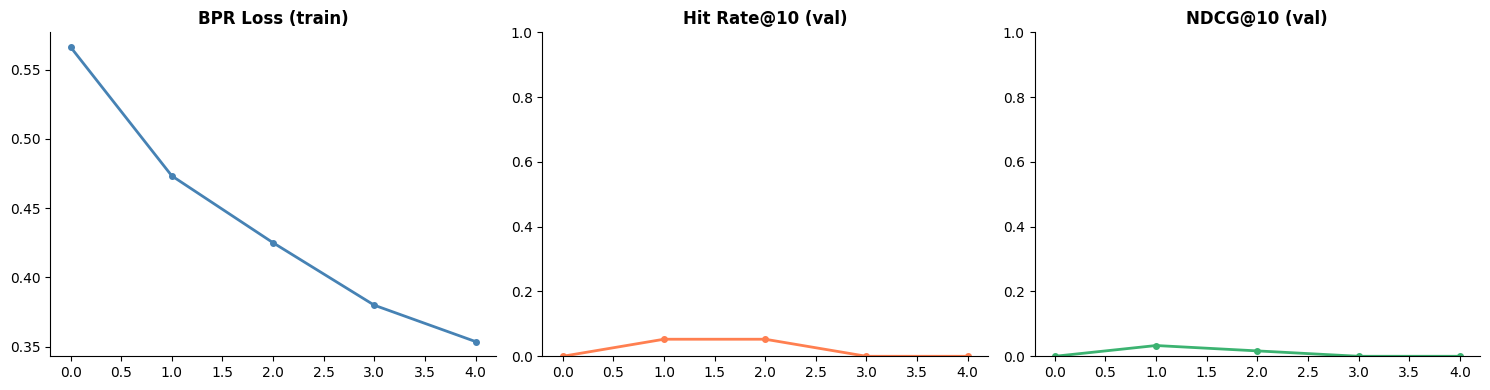

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('BPR Loss (train)', fontweight='bold')

axes[1].plot(history['val_hr'], color='coral', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Hit Rate@10 (val)', fontweight='bold')
axes[1].set_ylim(0, 1)

axes[2].plot(history['val_ndcg'], color='mediumseagreen', linewidth=2, marker='o', markersize=4)
axes[2].set_title('NDCG@10 (val)', fontweight='bold')
axes[2].set_ylim(0, 1)

for ax in axes: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/processed/06_training_curves.png', dpi=150)
plt.show()

In [9]:
test_hr   = hit_rate_at_k(model, test_df, N_MOVIES, k=10, n_users_eval=500)
test_ndcg = ndcg_at_k(model,    test_df, N_MOVIES, k=10, n_users_eval=500)

print('==============================')
print('   RÉSULTATS FINAUX — TEST    ')
print('==============================')
print(f'   Hit Rate@10 : {test_hr:.4f}')
print(f'   NDCG@10     : {test_ndcg:.4f}')
print('==============================')

torch.save({
    'model_state':  model.state_dict(),
    'model_config': {'n_users': N_USERS, 'n_movies': N_MOVIES,
                     'emb_dim': 64, 'mlp_layers': [256,128,64], 'dropout': 0.3},
    'metrics':      {'hit_rate_10': test_hr, 'ndcg_10': test_ndcg},
    'history':      history,
}, Path('../data/processed/ncf_model.pt'))
print('Modèle sauvegardé : data/processed/ncf_model.pt')

   RÉSULTATS FINAUX — TEST    
   Hit Rate@10 : 0.2353
   NDCG@10     : 0.1176
Modèle sauvegardé : data/processed/ncf_model.pt
